In this part only few variables are chosen to analyse core demographics, status of employment and programming languages used via PowerBI dashboard.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

Loading data:

In [ ]:
df_raw = pd.read_csv(r'data\results.txt') 

In [ ]:
schema_df = pd.read_csv(r'data\schema.txt') 

Checking # of rows with any nan values:

In [4]:
df_raw['ConvertedCompYearly'].isna().sum()

np.int64(42002)

Only keeping the relevant columns and then dropping nans.

In [5]:
selected_cols = ['ResponseId','Age', 'Country', 'EdLevel', 'MainBranch', 'Employment', 'YearsCode', 'LanguageHaveWorkedWith']
df = df_raw[selected_cols]

In [6]:
df_clean = df.dropna()

Checking whether leaving out rows with nans impacts distributions of chosen variables significantly.

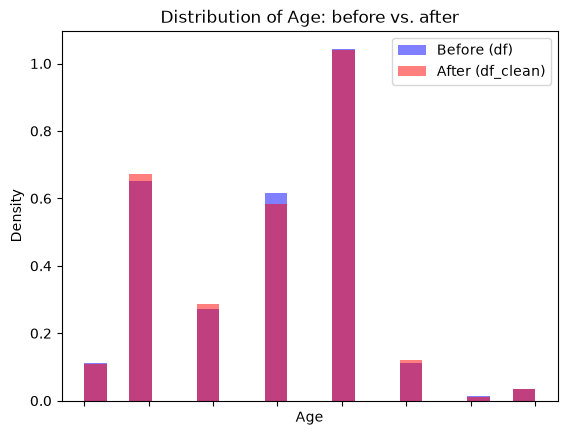

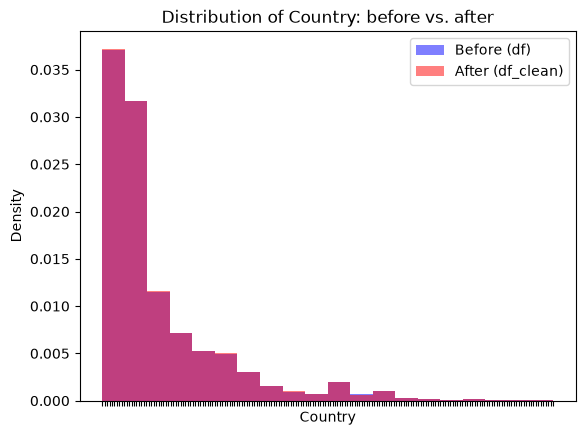

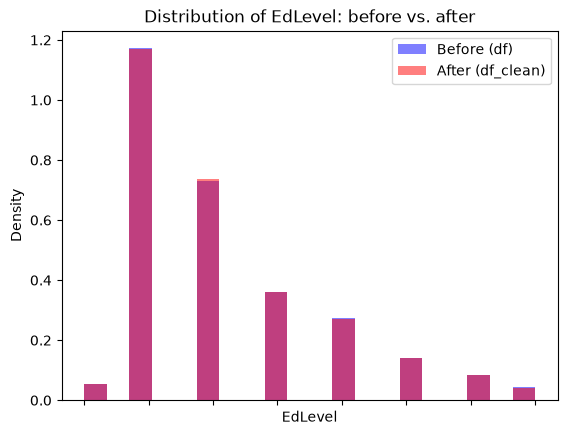

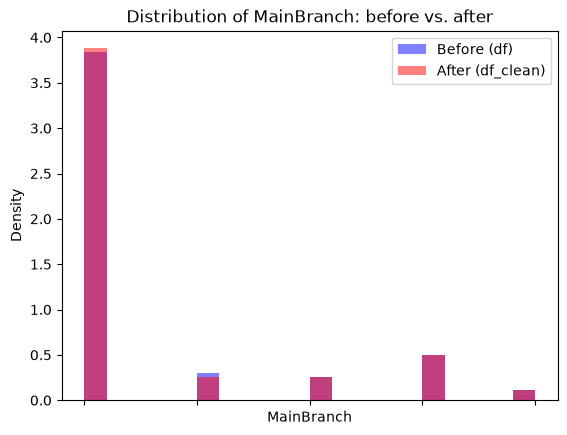

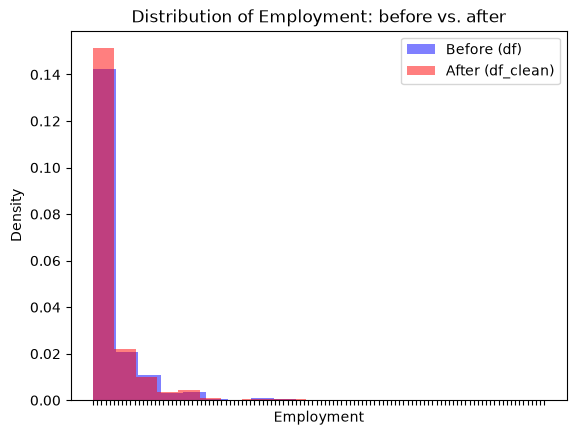

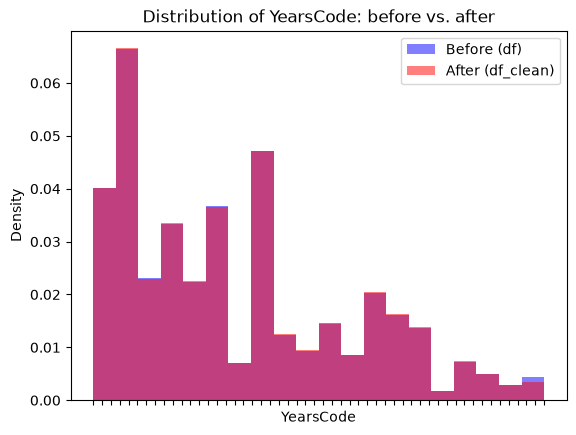

In [7]:
cols = ['Age', 'Country', 'EdLevel', 'MainBranch', 'Employment', 'YearsCode']
for col in cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=20, alpha=0.5, label='Before (df)', density=True, color='blue')
    plt.hist(df_clean[col], bins=20, alpha=0.5, label='After (df_clean)', density=True, color='red')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.title(f'Distribution of {col}: before vs. after')
    plt.tick_params(axis='x', labelbottom=False)
    plt.legend()
    plt.show()

Histograms show no substantial shift in distributions between df with and without nans.

Saving csv files, due to language and employment character, using explode.

In [8]:
df_clean.to_csv('respondents.csv', index=False)

In [9]:
lang_long = df_clean[['ResponseId', 'LanguageHaveWorkedWith']]
lang_long = lang_long.assign(Language=lang_long['LanguageHaveWorkedWith'].str.split(';')).explode('Language')
lang_long = lang_long[['ResponseId', 'Language']]
lang_long.to_csv('languages.csv', index=False)

In [10]:
df_clean['Employment'].head(20)

1                                   Employed, full-time
2                                   Employed, full-time
3                                    Student, full-time
4                                    Student, full-time
5                                    Student, full-time
6                                   Employed, full-time
7     Student, full-time;Not employed, but looking f...
8                                   Employed, full-time
9     Independent contractor, freelancer, or self-em...
10                                  Employed, full-time
11                                  Employed, full-time
12                                  Employed, full-time
13               Not employed, and not looking for work
14                                  Employed, full-time
15                                  Employed, full-time
16                                   Student, full-time
17    Independent contractor, freelancer, or self-em...
18                                  Employed, fu

In [11]:
emp_long = df_clean[['ResponseId', 'Employment']]
emp_long = emp_long.assign(EmploymentStatus=emp_long['Employment'].str.split(';')).explode('EmploymentStatus')
emp_long = emp_long[['ResponseId', 'EmploymentStatus']]
emp_long.to_csv('employment.csv', index=False)